In [1]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import skew

sns.set_style("whitegrid")

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [5]:
train = pd.read_csv("dataset/train.csv", index_col='Index')
display(train.sample(5))
train.info()

,geohash,day,timestamp,demand,RoadType,NumberofLanes,LargeVehicles,Landmarks,Temperature,Weather
Index,,,,,,,,,,
53493,qp096e,48,15:30,0.025097,Residential,1,Not Allowed,No,26.658369,Sunny
55068,qp09gx,48,16:0,0.023478,Residential,3,Allowed,Yes,21.462054,Sunny
18030,qp03p2,48,5:15,0.387683,Highway,5,Allowed,No,10.290469,Rainy
37506,qp03zm,48,10:30,0.005579,Residential,2,Not Allowed,Yes,27.264243,Sunny
48681,qp03wq,48,13:45,0.015012,Residential,2,Not Allowed,Yes,26.522493,Sunny


<class 'pandas.DataFrame'>
RangeIndex: 77299 entries, 0 to 77298
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   geohash        77299 non-null  str    
 1   day            77299 non-null  int64  
 2   timestamp      77299 non-null  str    
 3   demand         77299 non-null  float64
 4   RoadType       76699 non-null  str    
 5   NumberofLanes  77299 non-null  int64  
 6   LargeVehicles  77299 non-null  str    
 7   Landmarks      77299 non-null  str    
 8   Temperature    74804 non-null  float64
 9   Weather        76502 non-null  str    
dtypes: float64(2), int64(2), str(6)
memory usage: 5.9 MB


In [8]:
train.isnull().sum()

geohash             0
day                 0
timestamp           0
demand              0
RoadType          600
NumberofLanes       0
LargeVehicles       0
Landmarks           0
Temperature      2495
Weather           797
dtype: int64

In [9]:
train.duplicated().sum()

np.int64(0)

In [10]:
train['hour'] = pd.to_datetime(
    train['timestamp'],
    format='%H:%M'
).dt.hour

def traffic_period(hour):

    if 0 <= hour < 5:
        return 'Late Night'

    elif 5 <= hour < 8:
        return 'Early Morning'

    elif 8 <= hour < 11:
        return 'Morning Peak'

    elif 11 <= hour < 16:
        return 'Midday'

    elif 16 <= hour < 20:
        return 'Evening Peak'

    else:
        return 'Night'


train['traffic_period'] = train['hour'].apply(
    traffic_period
)

In [11]:
def temp_category(temp):

    if pd.isnull(temp):
        return 'Unknown'

    elif temp < 10:
        return 'Cold'

    elif temp < 20:
        return 'Cool'

    elif temp < 30:
        return 'Moderate'

    else:
        return 'Hot'


train['temp_category'] = train['Temperature'].apply(
    temp_category
)


In [12]:
def road_capacity(lanes):

    if lanes <= 2:
        return 'Low Capacity'

    elif lanes <= 4:
        return 'Medium Capacity'

    else:
        return 'High Capacity'


train['road_capacity'] = train['NumberofLanes'].apply(
    road_capacity
)

In [13]:
weather_map = {
    'Sunny': 'Clear',
    'Foggy': 'Moderate',
    'Rainy': 'Severe',
    'Snowy': 'Extreme'
}

train['weather_severity'] = train['Weather'].map(
    weather_map
)

In [32]:
q1 = train['demand'].quantile(0.33)
q2 = train['demand'].quantile(0.66)

def demand_level(d):

    if d <= q1:
        return 'Low Demand'

    elif d <= q2:
        return 'Medium Demand'

    else:
        return 'High Demand'


train['demand_level'] = train['demand'].apply(
    demand_level
)

In [14]:
display(train.describe())

,day,demand,NumberofLanes,Temperature,hour
count,77299.000000,7.729900e+04,77299.000000,74804.000000,77299.000000
mean,48.101838,9.394238e-02,2.014334,16.405354,9.101347
std,0.302438,1.421905e-01,0.904665,7.359835,6.856045
min,48.000000,6.245650e-07,1.000000,-14.935097,0.000000
25%,48.000000,1.822723e-02,1.000000,11.430473,3.000000
50%,48.000000,4.775994e-02,2.000000,16.382587,8.000000
75%,48.000000,1.085951e-01,3.000000,21.298833,14.000000
max,49.000000,1.000000e+00,5.000000,48.251433,23.000000


In [15]:
numerical_cols = [
    'Temperature',
    'demand',
    'hour'
]

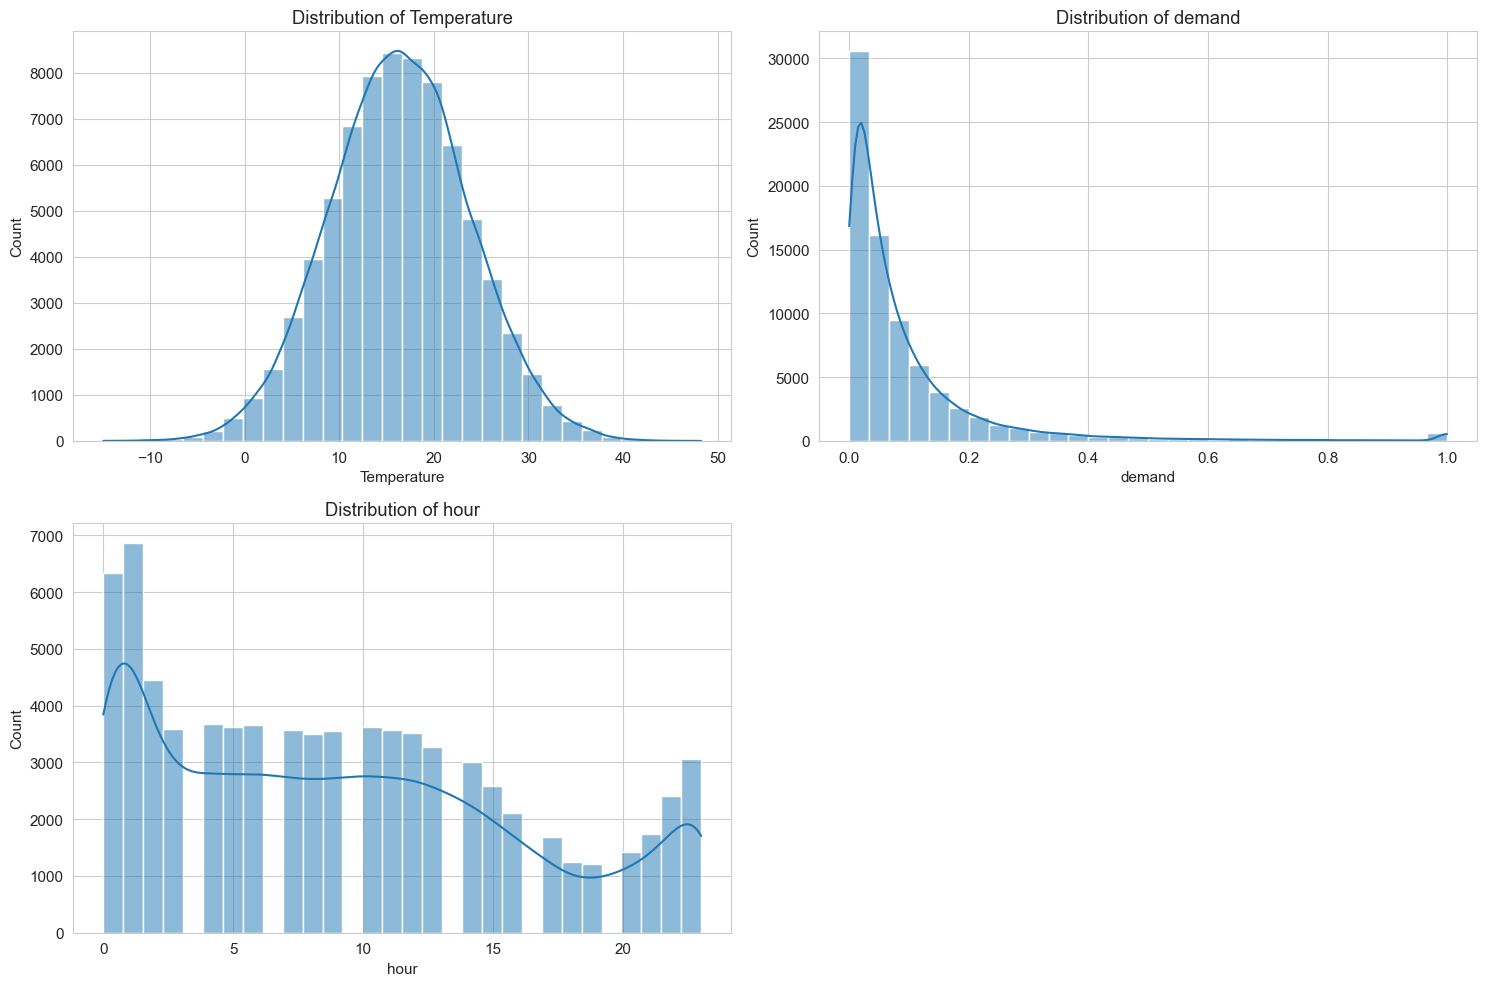

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.histplot(
        train[col],
        kde=True,
        bins=30,
        ax=axes[i]
    )

    axes[i].set_title(f"Distribution of {col}")

# Remove empty subplot
fig.delaxes(axes[3])

plt.tight_layout()
plt.show()

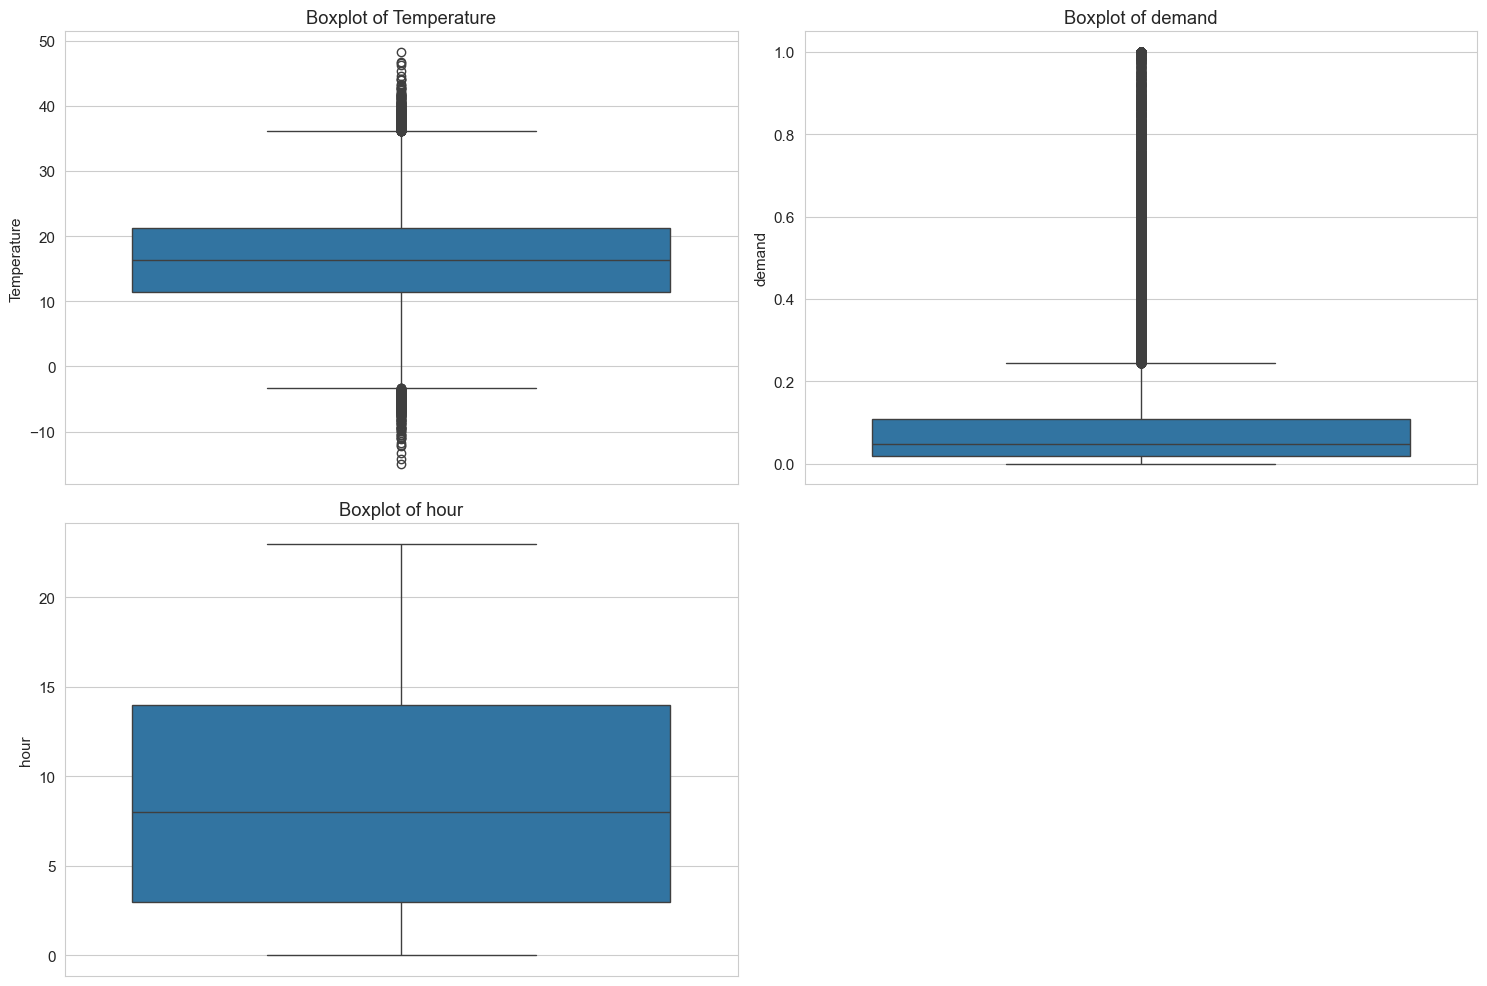

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(15,10))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):

    sns.boxplot(
        y=train[col],
        ax=axes[i]
    )

    axes[i].set_title(f"Boxplot of {col}")

fig.delaxes(axes[3])

plt.tight_layout()
plt.show()


In [18]:
for col in numerical_cols:

    print(
        f"{col}: {skew(train[col].dropna())}"
    )

Temperature: 0.02159553030391028
demand: 3.7284449358411953
hour: 0.4493619182321909


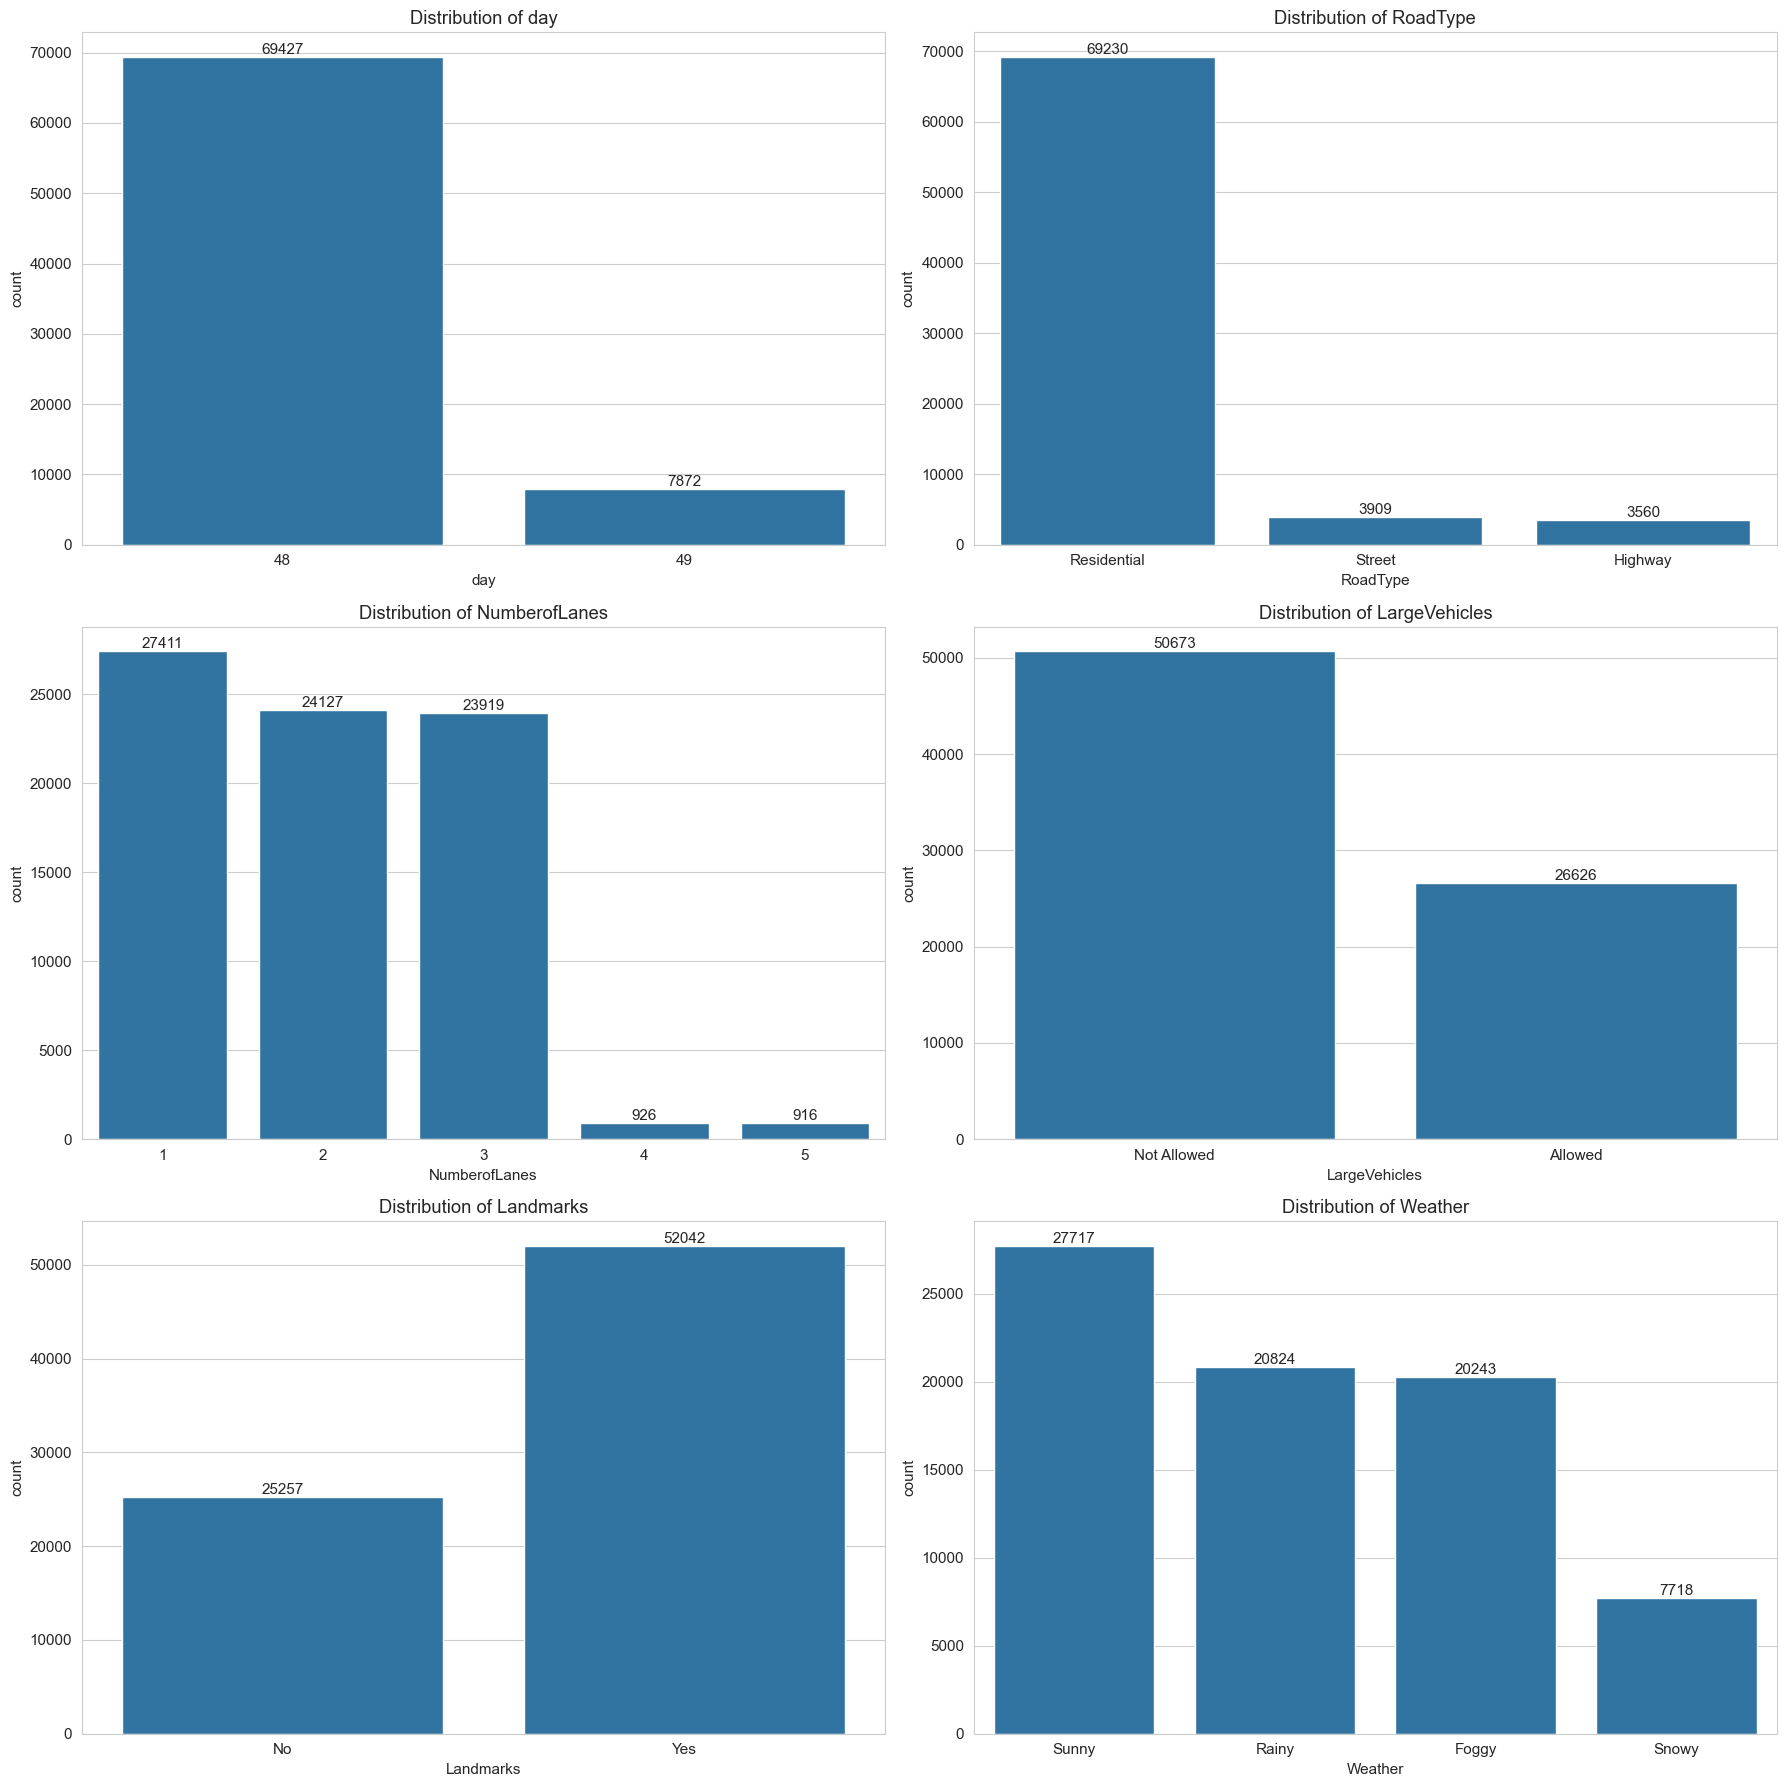

In [20]:
categorical_cols = [
    'day',
    'RoadType',
    'NumberofLanes',
    'LargeVehicles',
    'Landmarks',
    'Weather'
]

fig, axes = plt.subplots(3, 2, figsize=(18,18))

axes = axes.flatten()

for i, col in enumerate(categorical_cols):

    ax = axes[i]

    sns.countplot(
        x=train[col],
        ax=ax
    )

    ax.set_title(f"Distribution of {col}")

    for container in ax.containers:
        ax.bar_label(container)

plt.tight_layout()
plt.show()


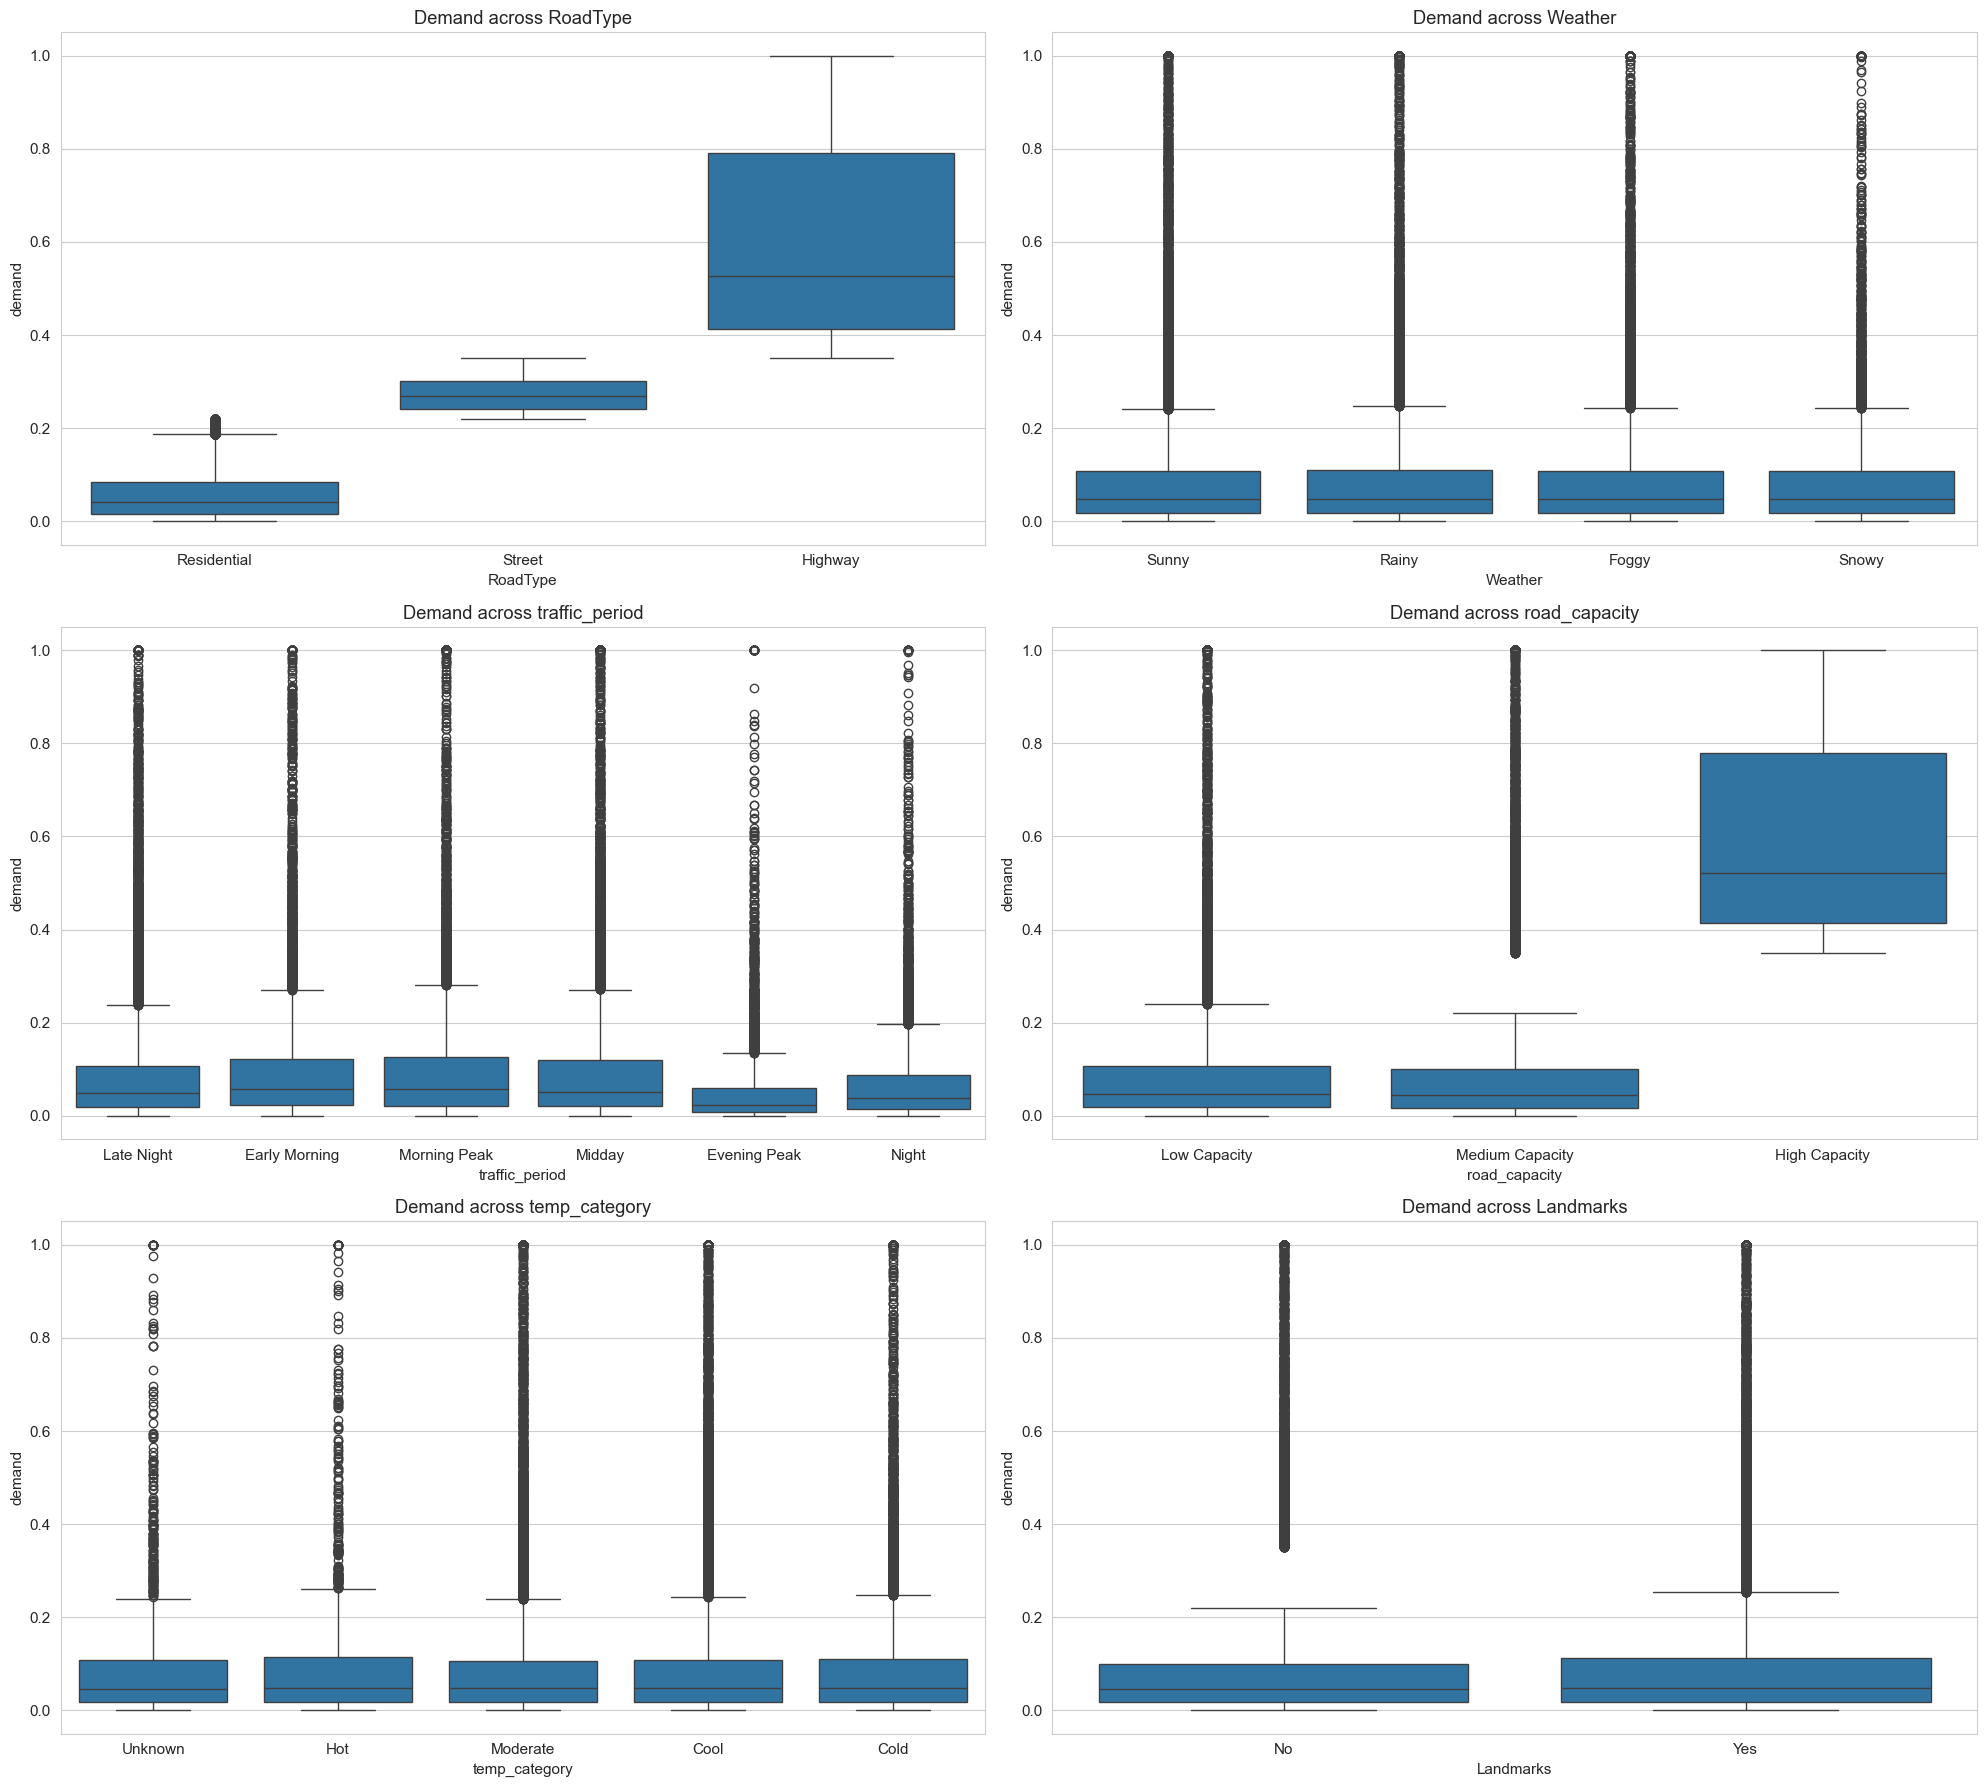

In [24]:
eda_cols = [
    'RoadType',
    'Weather',
    'traffic_period',
    'road_capacity',
    'temp_category',
    'Landmarks'
]

fig, axes = plt.subplots(3, 2, figsize=(20,18))

axes = axes.flatten()

for i, col in enumerate(eda_cols):

    sns.boxplot(
        x=col,
        y='demand',
        data=train,
        ax=axes[i]
    )

    axes[i].set_title(
        f"Demand across {col}"
    )

plt.tight_layout()
plt.show()

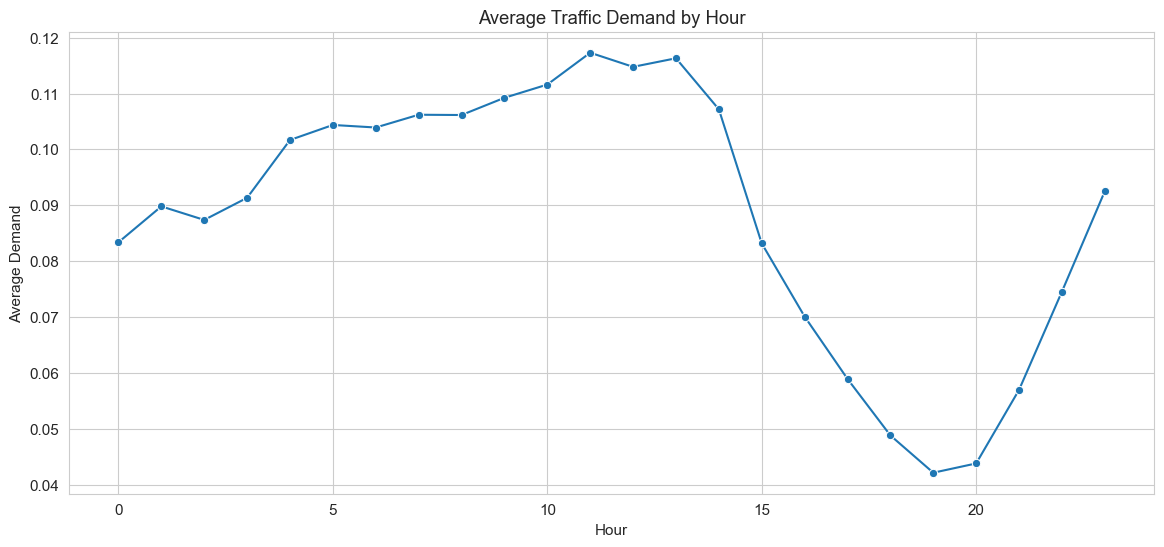

In [25]:
hourly = train.groupby(
    'hour'
)['demand'].mean()

plt.figure(figsize=(14,6))

sns.lineplot(
    x=hourly.index,
    y=hourly.values,
    marker='o'
)

plt.title(
    "Average Traffic Demand by Hour"
)

plt.xlabel("Hour")
plt.ylabel("Average Demand")

plt.show()

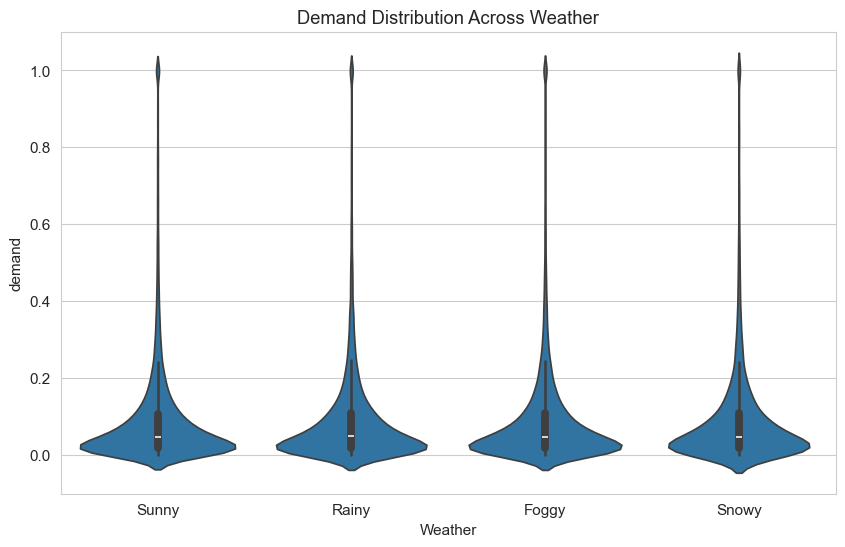

In [26]:
plt.figure(figsize=(10,6))

sns.violinplot(
    x='Weather',
    y='demand',
    data=train
)

plt.title(
    "Demand Distribution Across Weather"
)

plt.show()

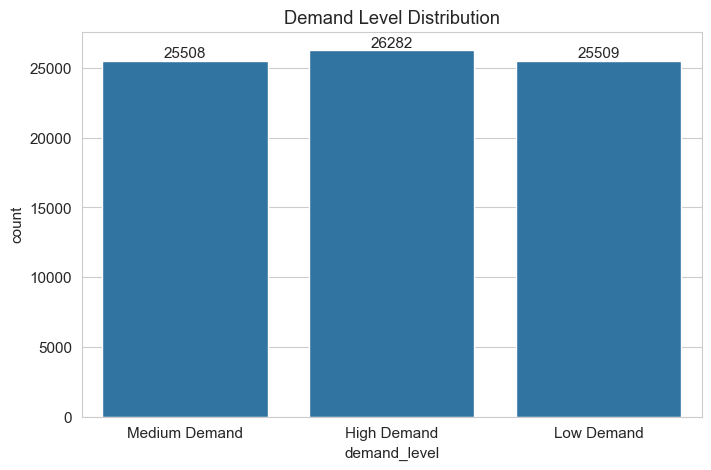

In [33]:
plt.figure(figsize=(8,5))

ax = sns.countplot(
    x='demand_level',
    data=train
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Demand Level Distribution"
)

plt.show()


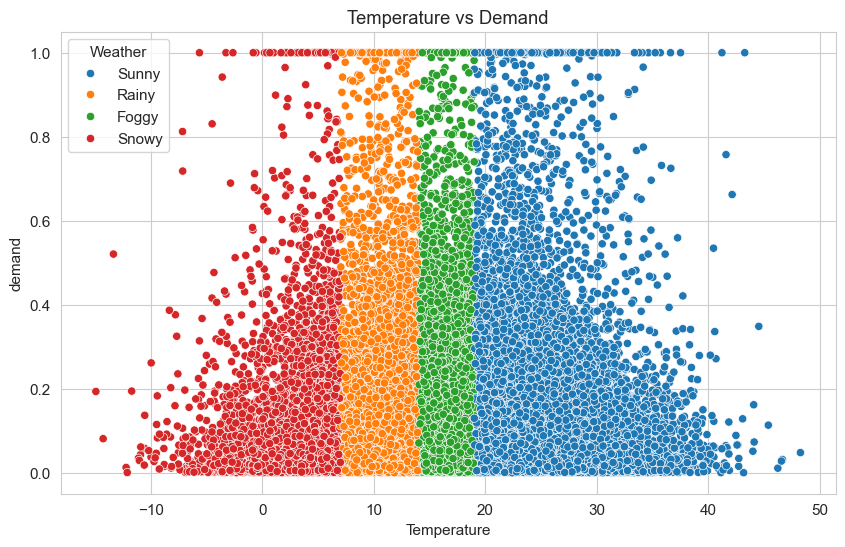

In [28]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x='Temperature',
    y='demand',
    hue='Weather',
    data=train
)

plt.title(
    "Temperature vs Demand"
)

plt.show()


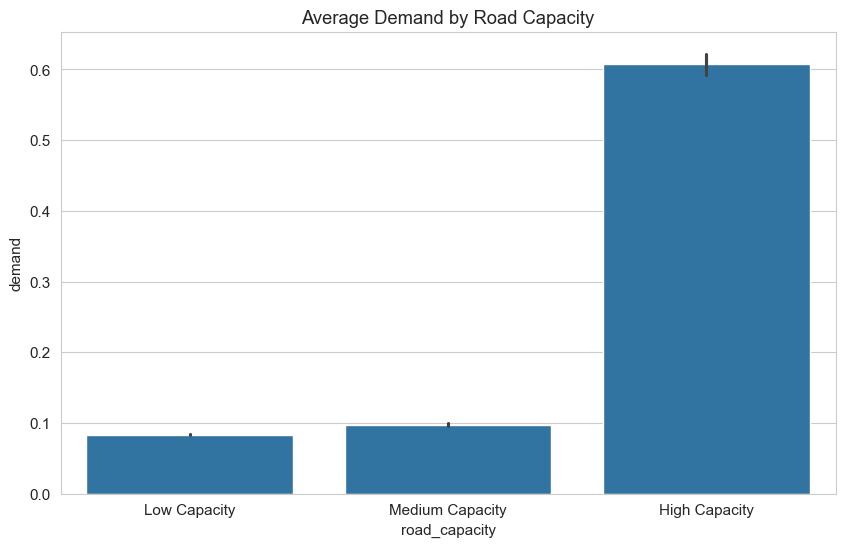

In [29]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='road_capacity',
    y='demand',
    data=train,
    estimator=np.mean
)

plt.title(
    "Average Demand by Road Capacity"
)

plt.show()

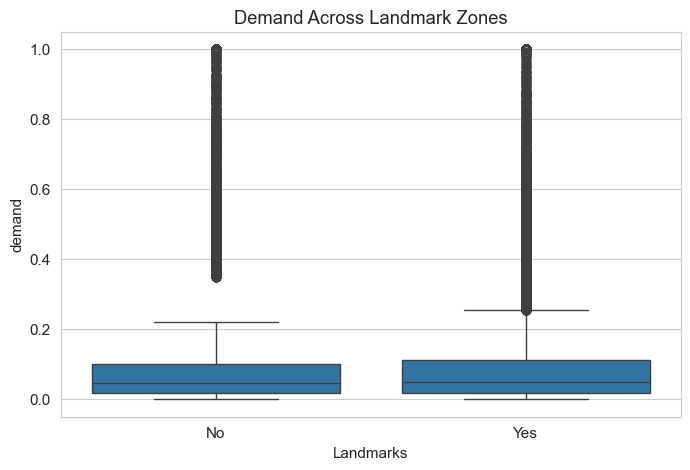

In [30]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Landmarks',
    y='demand',
    data=train
)

plt.title(
    "Demand Across Landmark Zones"
)

plt.show()

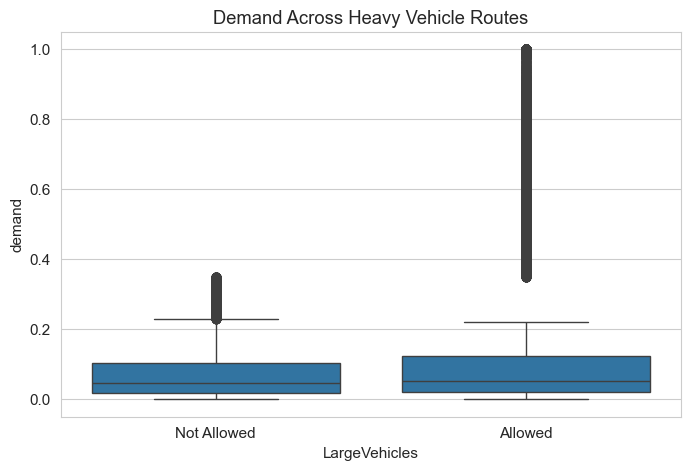

In [31]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='LargeVehicles',
    y='demand',
    data=train
)

plt.title(
    "Demand Across Heavy Vehicle Routes"
)

plt.show()

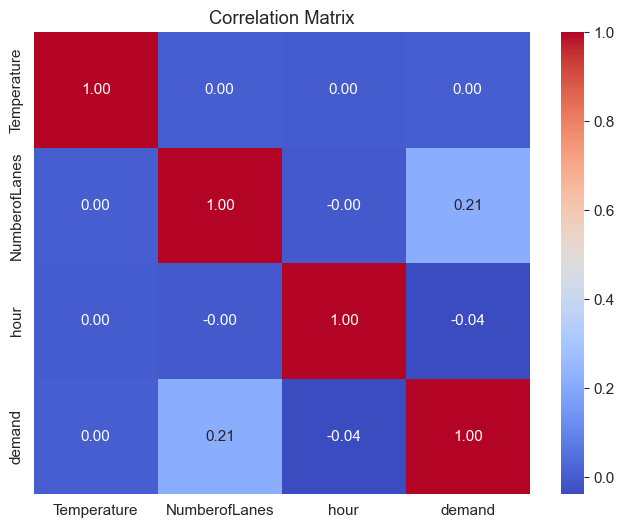

In [34]:
corr_cols = [
    'Temperature',
    'NumberofLanes',
    'hour',
    'demand'
]

corr = train[corr_cols].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

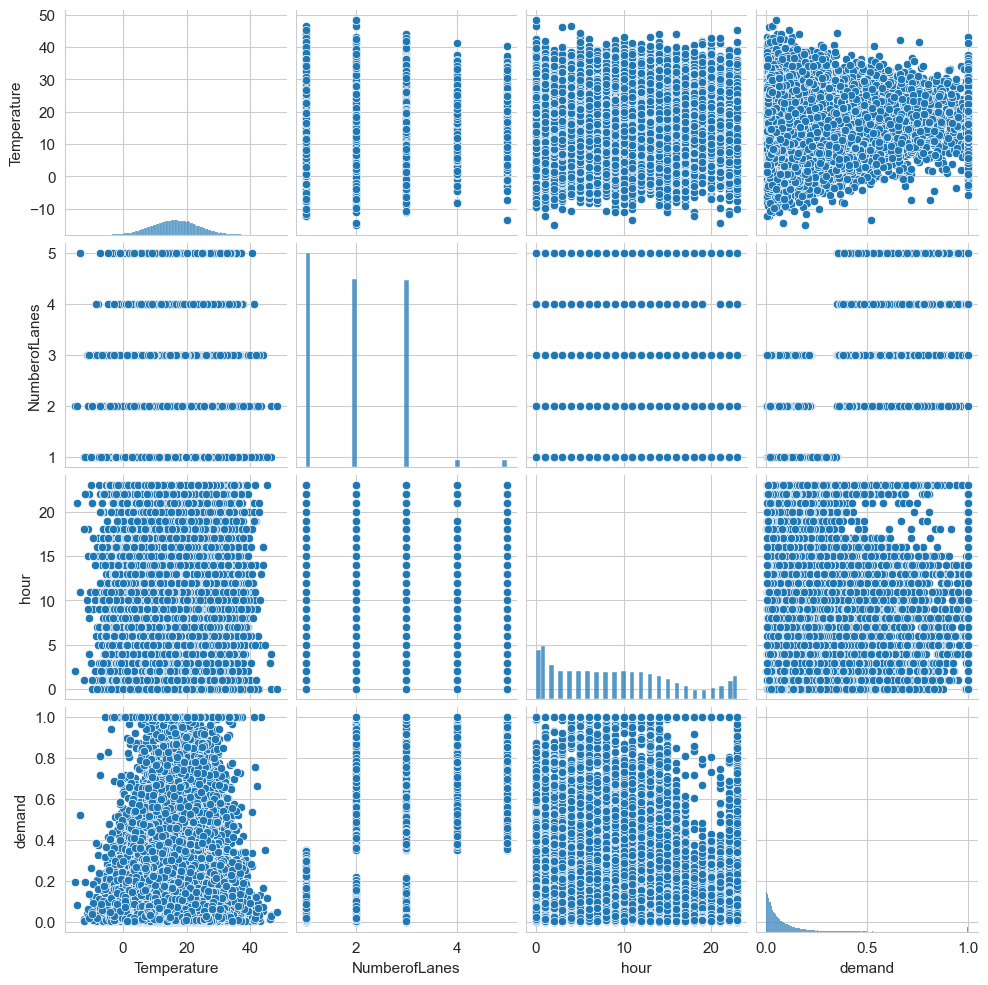

In [35]:
sns.pairplot(
    train[
        [
            'Temperature',
            'NumberofLanes',
            'hour',
            'demand'
        ]
    ]
)

plt.show()

In [36]:
Q1 = train['demand'].quantile(0.25)
Q3 = train['demand'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = train[
    (train['demand'] < lower) |
    (train['demand'] > upper)
]

print("="*60)
print("OUTLIER ANALYSIS")
print("="*60)

print(f"Lower Bound: {lower}")
print(f"Upper Bound: {upper}")
print(f"Number of Outliers: {len(outliers)}")


OUTLIER ANALYSIS
Lower Bound: -0.1173245953664149
Upper Bound: 0.2441469424341723
Number of Outliers: 6413


In [38]:
print("AVERAGE DEMAND BY WEATHER")

display(
    train.groupby('Weather')['demand']
    .agg(['mean', 'median', 'max', 'min'])
)

print("AVERAGE DEMAND BY ROAD TYPE")

display(
    train.groupby('RoadType')['demand']
    .agg(['mean', 'median', 'max', 'min'])
)

AVERAGE DEMAND BY WEATHER


,mean,median,max,min
Weather,,,,
Foggy,0.093372,0.047571,1.0,6.138162e-06
Rainy,0.094471,0.048467,1.0,7.981559e-07
Snowy,0.092581,0.047775,1.0,3.994529e-06
Sunny,0.094247,0.047230,1.0,6.245650e-07


AVERAGE DEMAND BY ROAD TYPE


,mean,median,max,min
RoadType,,,,
Highway,0.610756,0.526432,1.000000,3.500089e-01
Residential,0.057209,0.040517,0.219997,6.245650e-07
Street,0.273164,0.268124,0.349908,2.200159e-01


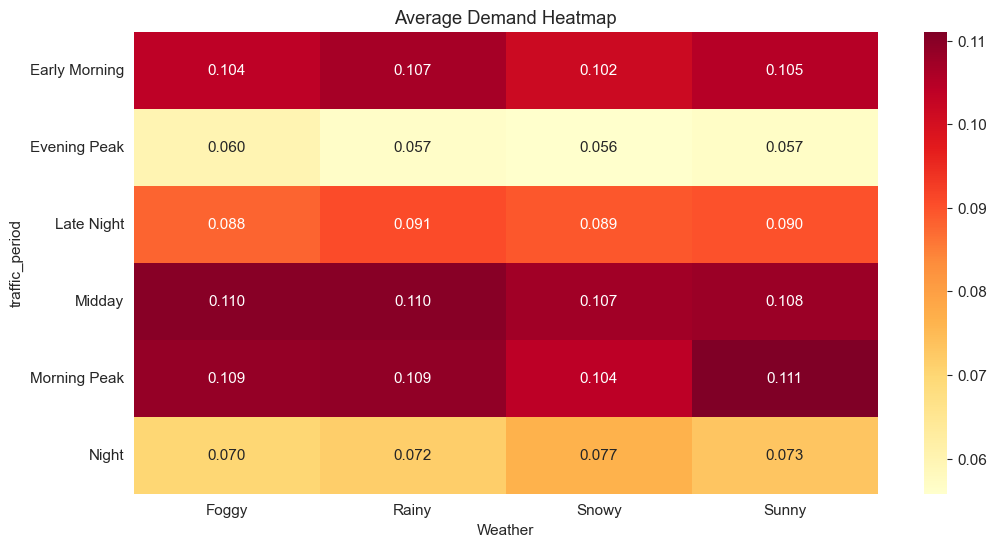

In [39]:
pivot = pd.pivot_table(
    train,
    values='demand',
    index='traffic_period',
    columns='Weather',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))

sns.heatmap(
    pivot,
    annot=True,
    cmap='YlOrRd',
    fmt='.3f'
)

plt.title(
    "Average Demand Heatmap"
)

plt.show()

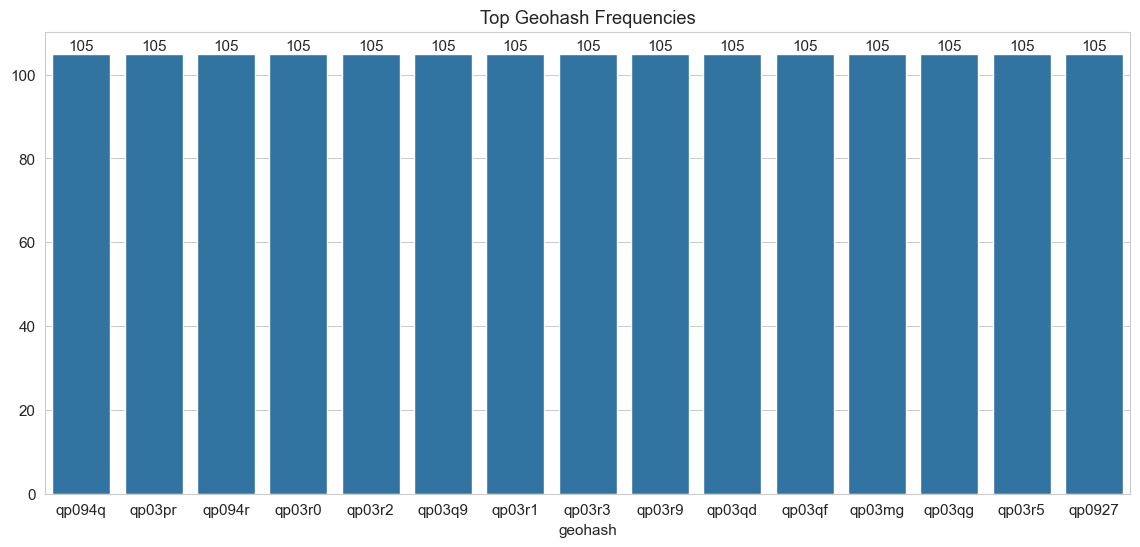

In [41]:
top_geo = train['geohash'].value_counts().head(15)

plt.figure(figsize=(14,6))

ax = sns.barplot(
    x=top_geo.index,
    y=top_geo.values
)

for container in ax.containers:
    ax.bar_label(container)

plt.title(
    "Top Geohash Frequencies"
)


plt.show()